# Blood Cell Cancer Classification

In [1]:
import os 
print(os.getcwd())

C:\Users\HPC\Documents\Blood_Cancer


In [2]:
path = r"C:\Users\HPC\Documents\Blood_Cancer"
subfolder = os.path.join(path, "Blood cell Cancer")
folders = os.listdir(subfolder)
folders

['Benign', '[Malignant] early Pre-B', '[Malignant] Pre-B', '[Malignant] Pro-B']

In [3]:
# 4 classes path

benign = os.path.join(subfolder, "Benign")
malignant_early_preb = os.path.join(subfolder, "[Malignant] early Pre-B")
malignant_preb = os.path.join(subfolder, "[Malignant] Pre-B")
malignant_prob = os.path.join(subfolder, "[Malignant] Pro-B")

In [4]:
print(len(os.listdir(benign)))
print(len(os.listdir(malignant_early_preb)))
print(len(os.listdir(malignant_preb)))
print(len(os.listdir(malignant_prob)))

512
979
955
756


# Data Visualization

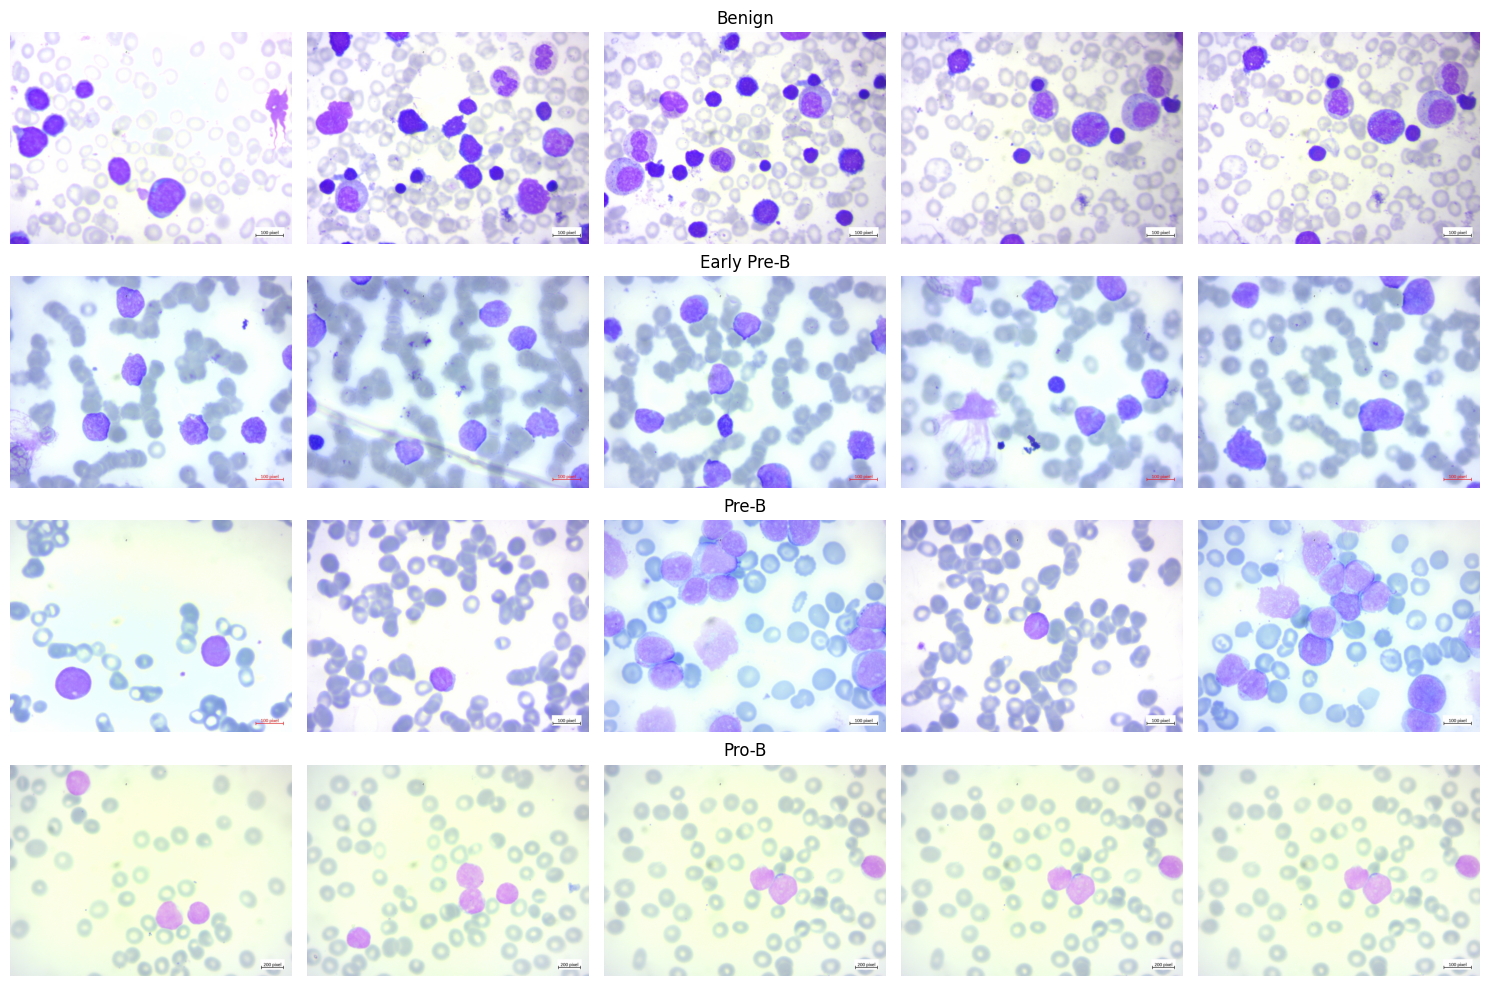

In [5]:
# Visualize sample images for each class

import os
import cv2
import matplotlib.pyplot as plt

# Store class paths
class_paths = [benign, malignant_early_preb, malignant_preb, malignant_prob]

# Class names for titles
class_names = ["Benign", "Early Pre-B", "Pre-B", "Pro-B"]

# Create plot
plt.figure(figsize=(15,10))

for i, path in enumerate(class_paths):

    images = os.listdir(path)[:5]   # first 5 images
    
    for j, img_name in enumerate(images):
        
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(4,5,i*5 + j + 1)
        plt.imshow(img)
        plt.axis("off")
        
        if j == 2:
            plt.title(class_names[i], fontsize=12)

plt.tight_layout()
plt.show()

# cheking duplicates

In [6]:
import hashlib #creates a unique hash value for each image
import os

def get_image_hash(image_path):
    with open(image_path, "rb") as f:
        img_bytes = f.read()
        return hashlib.md5(img_bytes).hexdigest()

class_paths = [benign, malignant_early_preb, malignant_preb, malignant_prob]

hash_dict = {}
duplicates = []

for folder in class_paths:
    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)
        img_hash = get_image_hash(img_path)

        if img_hash in hash_dict:
            duplicates.append(img_path)
        else:
            hash_dict[img_hash] = img_path

print("Total duplicate images:", len(duplicates))

Total duplicate images: 0


In [39]:
# remove duplicates

for img in duplicates:
    os.remove(img)

print("Removed duplicate images:", len(duplicates))

Removed duplicate images: 40


In [40]:
print(len(os.listdir(benign)))
print(len(os.listdir(malignant_early_preb)))
print(len(os.listdir(malignant_preb)))
print(len(os.listdir(malignant_prob)))

512
979
955
756


# Check corrupted images

In [7]:
from PIL import Image

class_paths = [benign, malignant_early_preb, malignant_preb, malignant_prob]

corrupted_images = []

for folder in class_paths:
    for img in os.listdir(folder):
        img_path = os.path.join(folder, img)

        try:
            image = Image.open(img_path)
            image.verify()
        except:
            corrupted_images.append(img_path)          #If an image cannot be opened, it will be added to corrupted_images.

len(corrupted_images)

0

# Check Image Dimensions

In [14]:
import cv2
import os

# list of class folders
class_paths = [benign, malignant_early_preb, malignant_preb, malignant_prob]

for folder in class_paths:
    
    sample_image = os.listdir(folder)[0]
    
    img_path = os.path.join(folder, sample_image)
    
    img = cv2.imread(img_path)
    
    print(folder, "→", img.shape)

C:\Users\HPC\Documents\Blood_Cancer\Blood cell Cancer\Benign → (768, 1024, 3)
C:\Users\HPC\Documents\Blood_Cancer\Blood cell Cancer\[Malignant] early Pre-B → (768, 1024, 3)
C:\Users\HPC\Documents\Blood_Cancer\Blood cell Cancer\[Malignant] Pre-B → (768, 1024, 3)
C:\Users\HPC\Documents\Blood_Cancer\Blood cell Cancer\[Malignant] Pro-B → (1920, 2560, 3)


# Check Unique images shape

In [15]:
sizes = set()

for folder in class_paths:
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        
        if img is not None:
            sizes.add(img.shape)

print(sizes)

{(768, 1024, 3), (1920, 2560, 3)}


# Resize the Image

In [16]:
# Test Resizing on One Image

img_resized = cv2.resize(img, (224,224))

img_resized.shape

(224, 224, 3)

# Check pixel value range of images.

In [17]:
img.min(), img.max()           # 0- black and 255- white

(np.uint8(0), np.uint8(255))

# Normalaization

In [18]:
# Test normalization on your sample image

img_normalized = img / 255

img_normalized.min(), img_normalized.max()

(np.float64(0.0), np.float64(1.0))

# Visualize Class Distribution

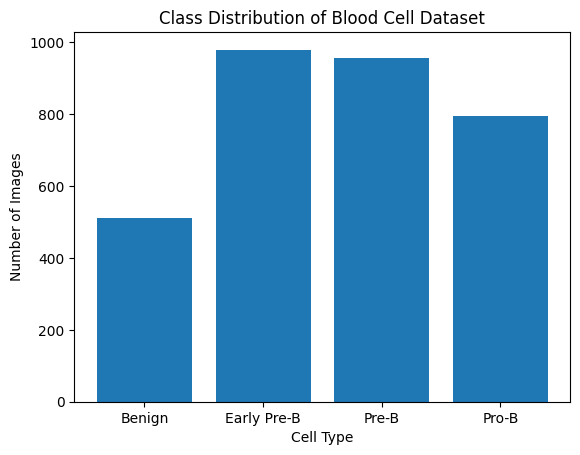

In [19]:
import matplotlib.pyplot as plt

classes = ["Benign", "Early Pre-B", "Pre-B", "Pro-B"]
counts = [512, 979, 955, 796]

plt.bar(classes, counts)
plt.title("Class Distribution of Blood Cell Dataset")
plt.xlabel("Cell Type")
plt.ylabel("Number of Images")
plt.show()

# Create dataset dataframe

In [20]:
import pandas as pd

data = []
labels = []

folders = {
    "Benign": benign,
    "Early_Pre_B": malignant_early_preb,
    "Pre_B": malignant_preb,
    "Pro_B": malignant_prob
}

for label, folder in folders.items():
    
    for img in os.listdir(folder):
        
        img_path = os.path.join(folder, img)
        
        data.append(img_path)
        labels.append(label)

df = pd.DataFrame({
    "image_path": data,
    "label": labels
})

df.head()

,image_path,label
0,C:\Users\HPC\Documents\Blood_Cancer\Blood cell...,Benign
1,C:\Users\HPC\Documents\Blood_Cancer\Blood cell...,Benign
2,C:\Users\HPC\Documents\Blood_Cancer\Blood cell...,Benign
3,C:\Users\HPC\Documents\Blood_Cancer\Blood cell...,Benign
4,C:\Users\HPC\Documents\Blood_Cancer\Blood cell...,Benign


In [21]:
df.shape
df["label"].value_counts()

label
Early_Pre_B    979
Pre_B          955
Pro_B          756
Benign         512
Name: count, dtype: int64

# Train/Test/Validation

In [22]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

print("Train size:", len(train_df))
print("Temp size:", len(temp_df))


val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 2241
Temp size: 961
Validation size: 480
Test size: 481


# Verify Class Balance

In [25]:
import pandas as pd

distribution = pd.DataFrame({
    "Train": train_df["label"].value_counts(),
    "Validation": val_df["label"].value_counts(),
    "Test": test_df["label"].value_counts()
})

print(distribution)

             Train  Validation  Test
label                               
Early_Pre_B    685         147   147
Pre_B          669         143   143
Pro_B          529         113   114
Benign         358          77    77


# Create Image Data Generators

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(            # Train generator
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_val_datagen = ImageDataGenerator(rescale=1./255)         # test and validation generator

# Create Training Generator

In [28]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

Found 2241 validated image filenames belonging to 4 classes.


# Create Validation Generator

In [29]:
validation_generator = test_val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 480 validated image filenames belonging to 4 classes.


# Create Test Generator

In [30]:
test_generator = test_val_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 481 validated image filenames belonging to 4 classes.


# check class index mapping 

In [31]:
print(train_generator.class_indices)
print(test_generator.class_indices)
print(validation_generator.class_indices)

{'Benign': 0, 'Early_Pre_B': 1, 'Pre_B': 2, 'Pro_B': 3}
{'Benign': 0, 'Early_Pre_B': 1, 'Pre_B': 2, 'Pro_B': 3}
{'Benign': 0, 'Early_Pre_B': 1, 'Pre_B': 2, 'Pro_B': 3}


# Model Building

# 1. Custom CNN

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model_cnn = Sequential()

# Input Layer
model_cnn.add(Input(shape=(224,224,3)))

# First Convolution Block
model_cnn.add(Conv2D(32, (3,3), activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Block
model_cnn.add(Conv2D(64, (3,3), activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Block
model_cnn.add(Conv2D(128, (3,3), activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2,2)))

# Fourth Convolution Block
model_cnn.add(Conv2D(256, (3,3), activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model_cnn.add(Flatten())

# Dense Layer
model_cnn.add(Dense(128, activation='relu'))

# Dropout
model_cnn.add(Dropout(0.5))

# Output Layer
model_cnn.add(Dense(4, activation='softmax'))

In [41]:
# compile the model

model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
model_cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,718,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,107,652 (19.48 MB)

 Trainable params: 5,107,652 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
history = model_cnn.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 61s 846ms/step - accuracy: 0.6265 - loss: 0.9200 - val_accuracy: 0.7812 - val_loss: 0.5250
Epoch 2/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 58s 814ms/step - accuracy: 0.7680 - loss: 0.5793 - val_accuracy: 0.8042 - val_loss: 0.5043
Epoch 3/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 58s 812ms/step - accuracy: 0.7515 - loss: 0.5943 - val_accuracy: 0.8083 - val_loss: 0.4411
Epoch 4/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 58s 812ms/step - accuracy: 0.8023 - loss: 0.5114 - val_accuracy: 0.8583 - val_loss: 0.3736
Epoch 5/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 58s 812ms/step - accuracy: 0.8068 - loss: 0.4934 - val_accuracy: 0.8396 - val_loss: 0.4267
Epoch 6/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 58s 812ms/step - accuracy: 0.8117 - loss: 0.4685 - val_accuracy: 0.8917 - val_loss: 0.2531
Epoch 7/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 58s 816ms/step - accuracy: 0.8264 - loss: 0.4952 - val_accuracy: 0.8938 - val_loss: 0.2694
Epoch 8/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 58s 810ms/step - accuracy: 0.8300 - loss: 0.4632 - val_accu

# evaluate on the test set.

In [44]:
test_loss, test_acc = model_cnn.evaluate(test_generator)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 272ms/step - accuracy: 0.9252 - loss: 0.2021
Test Accuracy: 0.9251559376716614
Test Loss: 0.20209640264511108


16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 276ms/step
['Benign', 'Early_Pre_B', 'Pre_B', 'Pro_B']
              precision    recall  f1-score   support

      Benign       0.82      0.70      0.76        77
 Early_Pre_B       0.88      0.95      0.92       147
       Pre_B       0.97      0.98      0.98       143
       Pro_B       0.99      0.97      0.98       114

    accuracy                           0.93       481
   macro avg       0.92      0.90      0.91       481
weighted avg       0.92      0.93      0.92       481



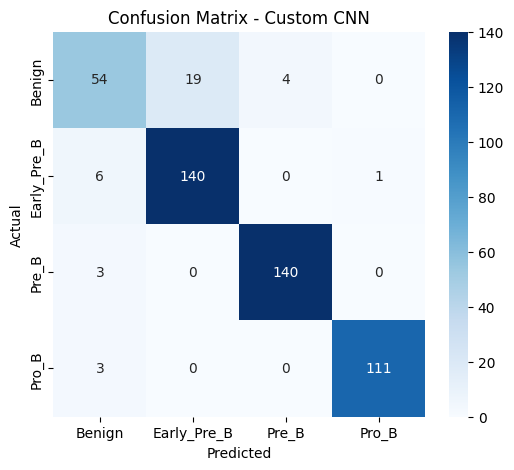

In [48]:
# Evaluation
import numpy as np

# prediction on test data
y_pred = model_cnn.predict(test_generator)

# convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# true labels
y_true = test_generator.classes

# class names
class_names = list(test_generator.class_indices.keys())
print(class_names)

# classification report
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=class_names))

# confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)
cm

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Custom CNN")
plt.show()

# Save CNN Model

In [47]:
model_cnn.save("custom_cnn_blood_cancer_model.keras")

# 2.VGG19

In [49]:
import tensorflow as tf

from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

# Load Pretrained VGG19 Model

In [50]:
base_model = VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze VGG19 Layers

In [51]:
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head

In [52]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = Dropout(0.5)(x)

output = Dense(4, activation='softmax')(x)

# create final model

In [53]:
model_vgg19 = Model(inputs=base_model.input, outputs=output)

model_vgg19.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg19.summary()

history_vgg19 = model_vgg19.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Model: "functional_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,156,740 (76.89 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 188s 3s/step - accuracy: 0.6283 - loss: 0.9354 - val_accuracy: 0.7937 - val_loss: 0.6145
Epoch 2/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 195s 3s/step - accuracy: 0.8063 - loss: 0.5765 - val_accuracy: 0.8521 - val_loss: 0.4614
Epoch 3/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 190s 3s/step - accuracy: 0.8559 - loss: 0.4304 - val_accuracy: 0.8875 - val_loss: 0.3681
Epoch 4/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 190s 3s/step - accuracy: 0.8871 - loss: 0.3432 - val_accuracy: 0.9062 - val_loss: 0.2937
Epoch 5/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.9032 - loss: 0.3078 - val_accuracy: 0.9083 - val_loss: 0.2709
Epoch 6/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 187s 3s/step - accuracy: 0.8983 - loss: 0.2840 - val_accuracy: 0.9250 - val_loss: 0.2191
Epoch 7/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.9192 - loss: 0.2432 - val_accuracy: 0.9250 - val_loss: 0.2076
Epoch 8/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 186s 3s/step - accuracy: 0.9197 - loss: 0.2303 - val_accuracy: 0.9458 - v

# Evaluate on test set

In [54]:
test_loss, test_acc = model_vgg19.evaluate(test_generator)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.9563 - loss: 0.1281
Test Accuracy: 0.9563409686088562
Test Loss: 0.1281263381242752


# VGG19 Model Evaluation

16/16 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step
['Benign', 'Early_Pre_B', 'Pre_B', 'Pro_B']
              precision    recall  f1-score   support

      Benign       0.97      0.84      0.90        77
 Early_Pre_B       0.93      0.95      0.94       147
       Pre_B       0.98      1.00      0.99       143
       Pro_B       0.95      0.99      0.97       114

    accuracy                           0.96       481
   macro avg       0.96      0.95      0.95       481
weighted avg       0.96      0.96      0.96       481

[[ 65   9   1   2]
 [  2 139   2   4]
 [  0   0 143   0]
 [  0   1   0 113]]


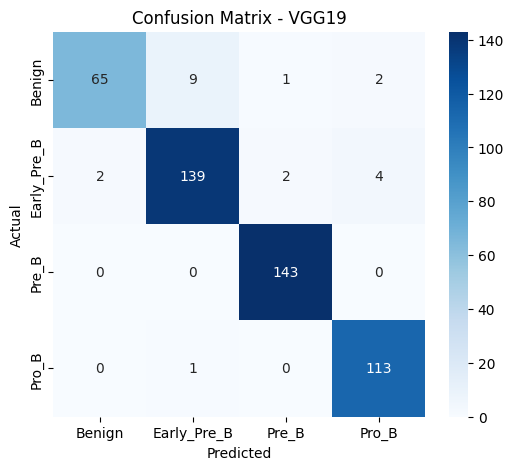

In [55]:
# Evaluation for VGG19 model

import numpy as np

# prediction on test data
y_pred_vgg19 = model_vgg19.predict(test_generator)

# convert probabilities to class labels
y_pred_classes = np.argmax(y_pred_vgg19, axis=1)

# true labels
y_true = test_generator.classes

# class names
class_names = list(test_generator.class_indices.keys())
print(class_names)

# classification report

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=class_names))

# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

# confusion matrix plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - VGG19")

plt.show()

# Save VGG19 Model

In [56]:
model_vgg19.save("vgg19_blood_cancer_model.keras")

# Load Saved Model

In [57]:
from tensorflow.keras.models import load_model

model_vgg19 = load_model("vgg19_blood_cancer_model.keras")

# Fine Tunning for VGG19

# Check vgg19 layers

In [60]:
for i, layer in enumerate(model_vgg19.layers):
    print(i, layer.name, layer.trainable)

0 input_layer_3 True
1 block1_conv1 False
2 block1_conv2 False
3 block1_pool False
4 block2_conv1 False
5 block2_conv2 False
6 block2_pool False
7 block3_conv1 False
8 block3_conv2 False
9 block3_conv3 False
10 block3_conv4 False
11 block3_pool False
12 block4_conv1 False
13 block4_conv2 False
14 block4_conv3 False
15 block4_conv4 False
16 block4_pool False
17 block5_conv1 False
18 block5_conv2 False
19 block5_conv3 False
20 block5_conv4 False
21 block5_pool False
22 global_average_pooling2d True
23 dense_6 True
24 dropout_3 True
25 dense_7 True


In [61]:
# freeze everything first

for layer in model_vgg19.layers:
    layer.trainable = False

# unfreeze block5

for layer in model_vgg19.layers[17:]:
    layer.trainable = True

# verify trainable layers
for layer in model_vgg19.layers:
    print(layer.name, layer.trainable)

input_layer_3 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_conv4 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_conv4 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_conv4 True
block5_pool True
global_average_pooling2d True
dense_6 True
dropout_3 True
dense_7 True


# Recompile model

In [62]:
from tensorflow.keras.optimizers import Adam

model_vgg19.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train fine tuned model

In [63]:
history_vgg19_finetune = model_vgg19.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 219s 3s/step - accuracy: 0.9415 - loss: 0.1657 - val_accuracy: 0.9604 - val_loss: 0.0930
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.9750 - loss: 0.0805 - val_accuracy: 0.9729 - val_loss: 0.0752
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.9768 - loss: 0.0669 - val_accuracy: 0.9771 - val_loss: 0.0488
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.9804 - loss: 0.0584 - val_accuracy: 0.9812 - val_loss: 0.0534
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.9763 - loss: 0.0722 - val_accuracy: 0.9771 - val_loss: 0.0549
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 221s 3s/step - accuracy: 0.9853 - loss: 0.0430 - val_accuracy: 0.9896 - val_loss: 0.0367
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 223s 3s/step - accuracy: 0.9888 - loss: 0.0350 - val_accuracy: 0.9833 - val_loss: 0.0400
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.9924 - loss: 0.0246 - val_accuracy: 0.9854 - v

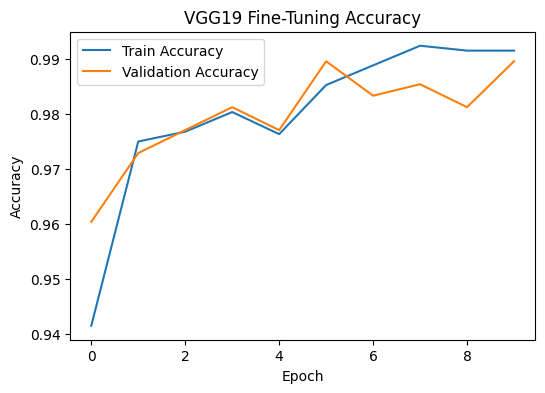

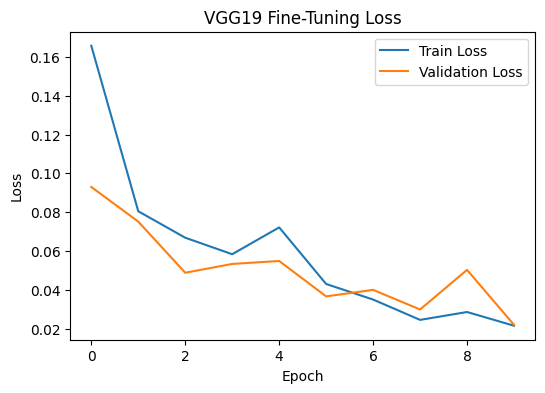

In [64]:
# plot for accuracy
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(6,4))

plt.plot(history_vgg19_finetune.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg19_finetune.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("VGG19 Fine-Tuning Accuracy")

plt.legend()
plt.show()

# plot for loss
# Loss plot
plt.figure(figsize=(6,4))

plt.plot(history_vgg19_finetune.history['loss'], label='Train Loss')
plt.plot(history_vgg19_finetune.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VGG19 Fine-Tuning Loss")

plt.legend()
plt.show()

In [65]:
# Evaluation

test_loss, test_acc = model_vgg19.evaluate(test_generator)

print("Fine-Tuned Test Accuracy:", test_acc)
print("Fine-Tuned Test Loss:", test_loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step - accuracy: 0.9854 - loss: 0.0381
Fine-Tuned Test Accuracy: 0.9854469895362854
Fine-Tuned Test Loss: 0.03805890306830406


16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step
['Benign', 'Early_Pre_B', 'Pre_B', 'Pro_B']
              precision    recall  f1-score   support

      Benign       0.99      0.94      0.96        77
 Early_Pre_B       0.96      0.99      0.98       147
       Pre_B       1.00      1.00      1.00       143
       Pro_B       1.00      0.99      1.00       114

    accuracy                           0.99       481
   macro avg       0.99      0.98      0.98       481
weighted avg       0.99      0.99      0.99       481

[[ 72   5   0   0]
 [  1 146   0   0]
 [  0   0 143   0]
 [  0   1   0 113]]


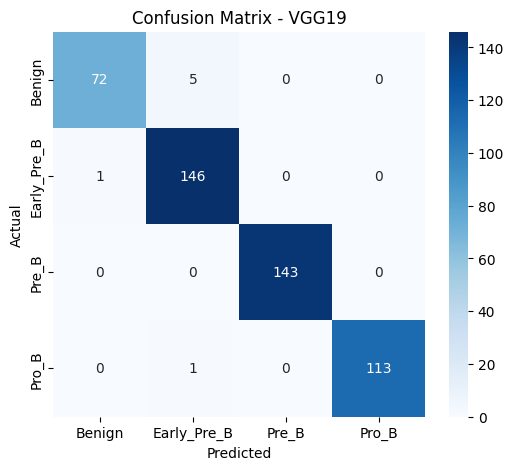

In [66]:
# Evaluation for tuned VGG19 model

import numpy as np

# prediction on test data
y_pred_tune_vgg19 = model_vgg19.predict(test_generator)

# convert probabilities to class labels
y_pred_classes = np.argmax(y_pred_tune_vgg19, axis=1)

# true labels
y_true = test_generator.classes

# class names
class_names = list(test_generator.class_indices.keys())
print(class_names)

# classification report

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=class_names))

# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

# confusion matrix plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - VGG19")

plt.show()

# Save tuned VGG19 model

In [67]:
model_vgg19.save("vgg19_finetuned_blood_cancer_model.keras")

# 3) MobileNetV2

In [72]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load pretrained base model
base_model_mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base layers
for layer in base_model_mobilenet.layers:
    layer.trainable = False

# Custom classifier
x = base_model_mobilenet.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(4, activation='softmax')(x)

# Final model
model_mobilenet = Model(inputs=base_model_mobilenet.input, outputs=output)

# Compile
model_mobilenet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Check model
model_mobilenet.summary()

Model: "functional_38"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [73]:
# Train the model

history_mobilenet = model_mobilenet.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 66s 888ms/step - accuracy: 0.5471 - loss: 1.1146 - val_accuracy: 0.8458 - val_loss: 0.5896
Epoch 2/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 61s 854ms/step - accuracy: 0.7898 - loss: 0.5957 - val_accuracy: 0.8854 - val_loss: 0.4227
Epoch 3/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 61s 860ms/step - accuracy: 0.8474 - loss: 0.4335 - val_accuracy: 0.9104 - val_loss: 0.3435
Epoch 4/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 62s 871ms/step - accuracy: 0.8840 - loss: 0.3516 - val_accuracy: 0.9187 - val_loss: 0.2937
Epoch 5/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 62s 872ms/step - accuracy: 0.8987 - loss: 0.3136 - val_accuracy: 0.9208 - val_loss: 0.2674
Epoch 6/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 61s 857ms/step - accuracy: 0.9139 - loss: 0.2639 - val_accuracy: 0.9271 - val_loss: 0.2381
Epoch 7/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 61s 861ms/step - accuracy: 0.9282 - loss: 0.2335 - val_accuracy: 0.9354 - val_loss: 0.2138
Epoch 8/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 61s 865ms/step - accuracy: 0.9224 - loss: 0.2210 - val_accu

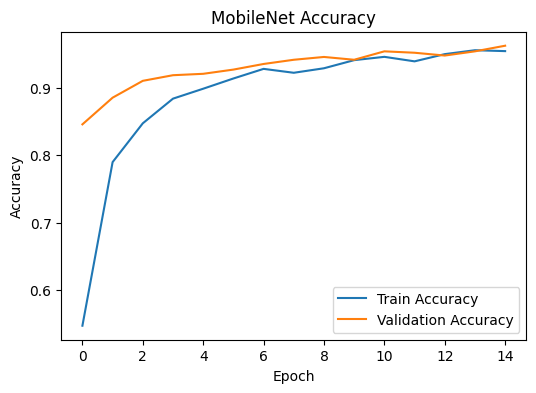

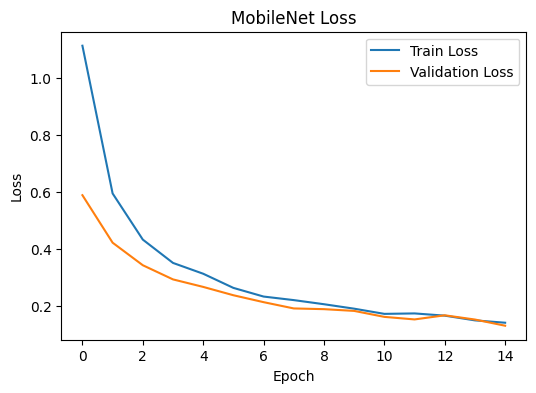

In [74]:
# plot for accuracy
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(6,4))

plt.plot(history_mobilenet.history['accuracy'], label='Train Accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNet Accuracy")

plt.legend()
plt.show()

# plot for loss
# Loss plot
plt.figure(figsize=(6,4))

plt.plot(history_mobilenet.history['loss'], label='Train Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNet Loss")

plt.legend()
plt.show()

In [75]:
# Evaluation

test_loss, test_acc = model_mobilenet.evaluate(test_generator)

print("Fine-Tuned Test Accuracy:", test_acc)
print("Fine-Tuned Test Loss:", test_loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 518ms/step - accuracy: 0.9667 - loss: 0.1138
Fine-Tuned Test Accuracy: 0.9667359590530396
Fine-Tuned Test Loss: 0.1137666329741478


16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 568ms/step
['Benign', 'Early_Pre_B', 'Pre_B', 'Pro_B']
              precision    recall  f1-score   support

      Benign       0.96      0.88      0.92        77
 Early_Pre_B       0.93      0.97      0.95       147
       Pre_B       0.99      0.99      0.99       143
       Pro_B       0.99      1.00      1.00       114

    accuracy                           0.97       481
   macro avg       0.97      0.96      0.96       481
weighted avg       0.97      0.97      0.97       481

[[ 68   9   0   0]
 [  3 142   1   1]
 [  0   2 141   0]
 [  0   0   0 114]]


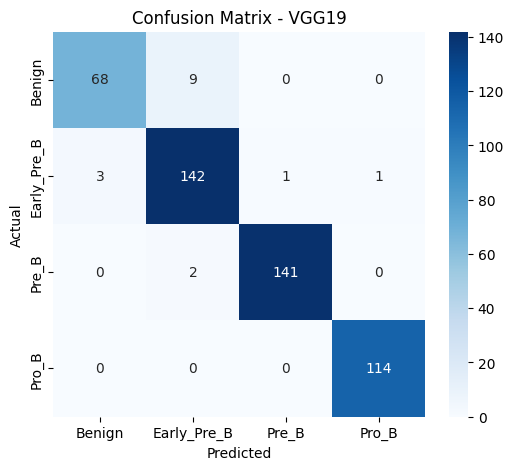

In [76]:
# Evaluation for MobileNet model

import numpy as np

# prediction on test data
y_pred_mobilenet = model_mobilenet.predict(test_generator)

# convert probabilities to class labels
y_pred_classes = np.argmax(y_pred_mobilenet, axis=1)

# true labels
y_true = test_generator.classes

# class names
class_names = list(test_generator.class_indices.keys())
print(class_names)

# classification report

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=class_names))

# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

# confusion matrix plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - mobilenet")

plt.show()

# Save MobileNet model

In [78]:
model_mobilenet.save("mobilenet_blood_cancer_model.keras")

# MobileNetV2 Fine-Tuning

In [79]:
# freeze everything
for layer in model_mobilenet.layers:
    layer.trainable = False

# unfreeze last mobilenet block
for layer in model_mobilenet.layers[-25:]:
    layer.trainable = True

# check trainable layers
for layer in model_mobilenet.layers:
    print(layer.name, layer.trainable)

# recompile
from tensorflow.keras.optimizers import Adam

model_mobilenet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mobilenet_finetune = model_mobilenet.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

input_layer_5 False
Conv1 False
bn_Conv1 False
Conv1_relu False
expanded_conv_depthwise False
expanded_conv_depthwise_BN False
expanded_conv_depthwise_relu False
expanded_conv_project False
expanded_conv_project_BN False
block_1_expand False
block_1_expand_BN False
block_1_expand_relu False
block_1_pad False
block_1_depthwise False
block_1_depthwise_BN False
block_1_depthwise_relu False
block_1_project False
block_1_project_BN False
block_2_expand False
block_2_expand_BN False
block_2_expand_relu False
block_2_depthwise False
block_2_depthwise_BN False
block_2_depthwise_relu False
block_2_project False
block_2_project_BN False
block_2_add False
block_3_expand False
block_3_expand_BN False
block_3_expand_relu False
block_3_pad False
block_3_depthwise False
block_3_depthwise_BN False
block_3_depthwise_relu False
block_3_project False
block_3_project_BN False
block_4_expand False
block_4_expand_BN False
block_4_expand_relu False
block_4_depthwise False
block_4_depthwise_BN False
block_4_d

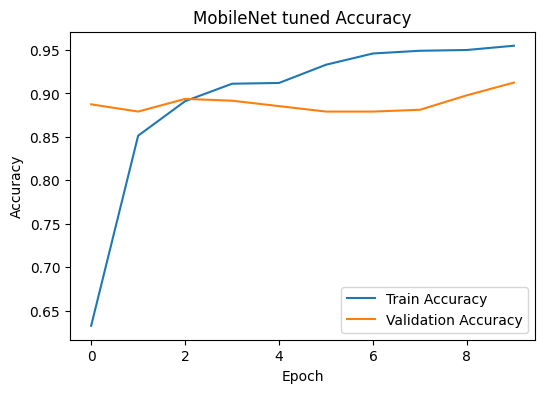

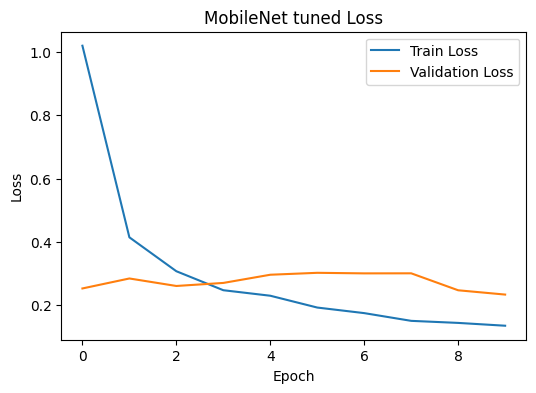

In [80]:
# plot for accuracy
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(6,4))

plt.plot(history_mobilenet_finetune.history['accuracy'], label='Train Accuracy')
plt.plot(history_mobilenet_finetune.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNet tuned Accuracy")

plt.legend()
plt.show()

# plot for loss
# Loss plot
plt.figure(figsize=(6,4))

plt.plot(history_mobilenet_finetune.history['loss'], label='Train Loss')
plt.plot(history_mobilenet_finetune.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNet tuned Loss")

plt.legend()
plt.show()

In [81]:
# Evaluation

test_loss, test_acc = model_mobilenet.evaluate(test_generator)

print("Fine-Tuned Test Accuracy:", test_acc)
print("Fine-Tuned Test Loss:", test_loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 524ms/step - accuracy: 0.9231 - loss: 0.2168
Fine-Tuned Test Accuracy: 0.9230769276618958
Fine-Tuned Test Loss: 0.21675851941108704


16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 586ms/step
['Benign', 'Early_Pre_B', 'Pre_B', 'Pro_B']
              precision    recall  f1-score   support

      Benign       0.97      0.82      0.89        77
 Early_Pre_B       0.93      0.93      0.93       147
       Pre_B       0.98      0.92      0.95       143
       Pro_B       0.83      1.00      0.91       114

    accuracy                           0.92       481
   macro avg       0.93      0.91      0.92       481
weighted avg       0.93      0.92      0.92       481

[[ 63   9   1   4]
 [  2 136   1   8]
 [  0   1 131  11]
 [  0   0   0 114]]


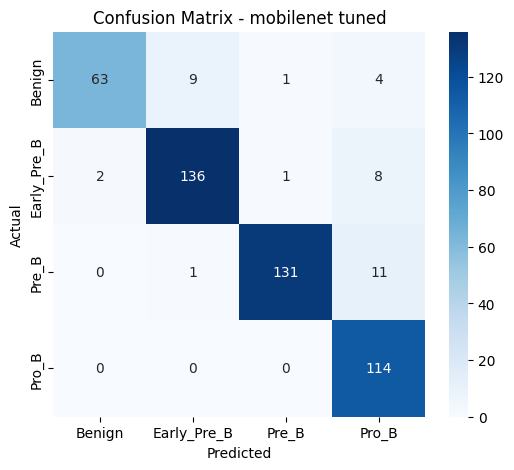

In [82]:
# Evaluation for MobileNet model

import numpy as np

# prediction on test data
y_pred_mobilenet_tuned = model_mobilenet.predict(test_generator)

# convert probabilities to class labels
y_pred_classes = np.argmax(y_pred_mobilenet_tuned, axis=1)

# true labels
y_true = test_generator.classes

# class names
class_names = list(test_generator.class_indices.keys())
print(class_names)

# classification report

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=class_names))

# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

# confusion matrix plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - mobilenet tuned")

plt.show()

# save mobilenet tuned model

In [84]:
model_mobilenet.save("mobilenet_tuned_blood_cancer_model.keras")

# 4) EfficientNetB0

In [93]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

# Note - EfficientNet requires preprocess_input, not rescale.

# Data Generators

In [98]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input


train_datagen1 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_val_datagen1 = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [103]:
train_generator1 = train_datagen1.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

validation_generator1 = test_val_datagen1.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical"
)

test_generator1 = test_val_datagen1.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

print(train_generator1.class_indices)

Found 2241 validated image filenames belonging to 4 classes.
Found 480 validated image filenames belonging to 4 classes.
Found 481 validated image filenames belonging to 4 classes.
{'Benign': 0, 'Early_Pre_B': 1, 'Pre_B': 2, 'Pro_B': 3}


In [104]:
# freeze base layers
for layer in base_model_efficient.layers:
    layer.trainable = False

x = base_model_efficient.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(4, activation='softmax')(x)

# train model
history_efficient = model_efficient.fit(
    train_generator1,
    validation_data=validation_generator1,
    epochs=15
)

Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.9313 - loss: 0.1950 - val_accuracy: 0.9521 - val_loss: 0.1243
Epoch 2/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 70s 982ms/step - accuracy: 0.9415 - loss: 0.1605 - val_accuracy: 0.9583 - val_loss: 0.1067
Epoch 3/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 70s 986ms/step - accuracy: 0.9465 - loss: 0.1549 - val_accuracy: 0.9667 - val_loss: 0.1043
Epoch 4/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 70s 987ms/step - accuracy: 0.9465 - loss: 0.1473 - val_accuracy: 0.9729 - val_loss: 0.1104
Epoch 5/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 70s 986ms/step - accuracy: 0.9429 - loss: 0.1528 - val_accuracy: 0.9729 - val_loss: 0.0975
Epoch 6/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 71s 993ms/step - accuracy: 0.9505 - loss: 0.1437 - val_accuracy: 0.9625 - val_loss: 0.1119
Epoch 7/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 70s 984ms/step - accuracy: 0.9549 - loss: 0.1313 - val_accuracy: 0.9479 - val_loss: 0.1310
Epoch 8/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 71s 995ms/step - accuracy: 0.9598 - loss: 0.1290 - val_accurac

In [105]:
# evaluate on test data
test_loss, test_acc = model_efficient.evaluate(test_generator1)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 614ms/step - accuracy: 0.9480 - loss: 0.1160
Test Accuracy: 0.9480249285697937
Test Loss: 0.11600297689437866


16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 734ms/step
['Benign', 'Early_Pre_B', 'Pre_B', 'Pro_B']
              precision    recall  f1-score   support

      Benign       0.94      0.83      0.88        77
 Early_Pre_B       0.96      0.93      0.94       147
       Pre_B       0.91      1.00      0.95       143
       Pro_B       0.99      0.98      0.99       114

    accuracy                           0.95       481
   macro avg       0.95      0.94      0.94       481
weighted avg       0.95      0.95      0.95       481

[[ 64   6   6   1]
 [  4 137   6   0]
 [  0   0 143   0]
 [  0   0   2 112]]


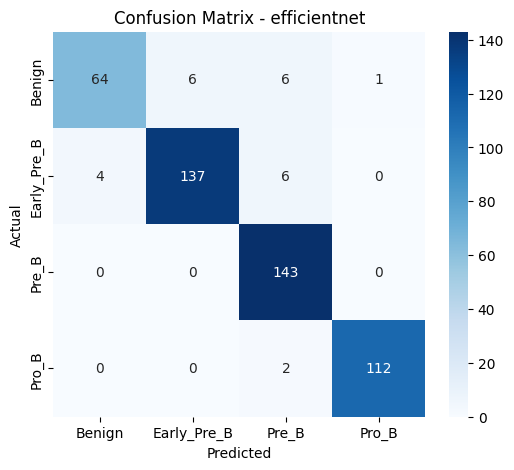

In [106]:
# Evaluation for MobileNet model

import numpy as np

# prediction on test data
y_pred_efficient = model_efficient.predict(test_generator1)

# convert probabilities to class labels
y_pred_classes = np.argmax(y_pred_efficient, axis=1)

# true labels
y_true = test_generator1.classes

# class names
class_names = list(test_generator1.class_indices.keys())
print(class_names)

# classification report

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=class_names))

# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

# confusion matrix plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - efficientnet")

plt.show()

# save EfficientNet model

In [107]:
model_efficient.save("efficientnet_blood_cancer_model.keras")

# EfficientNet Tuned model

In [108]:
# unfreeze last layers

for layer in base_model_efficient.layers[-20:]:
    layer.trainable = True

model_efficient.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_efficient_finetune = model_efficient.fit(
    train_generator1,
    validation_data=validation_generator1,
    epochs=10
)

Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.7684 - loss: 0.6419 - val_accuracy: 0.9750 - val_loss: 0.0954
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.8237 - loss: 0.4996 - val_accuracy: 0.9625 - val_loss: 0.1308
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.8452 - loss: 0.4243 - val_accuracy: 0.9458 - val_loss: 0.1640
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8652 - loss: 0.3643 - val_accuracy: 0.9354 - val_loss: 0.1864
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.8599 - loss: 0.3724 - val_accuracy: 0.9333 - val_loss: 0.1967
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8898 - loss: 0.2953 - val_accuracy: 0.9375 - val_loss: 0.1937
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8893 - loss: 0.2942 - val_accuracy: 0.9396 - val_loss: 0.1871
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.9050 - loss: 0.2802 - val_accuracy: 0.9438 - val_loss:

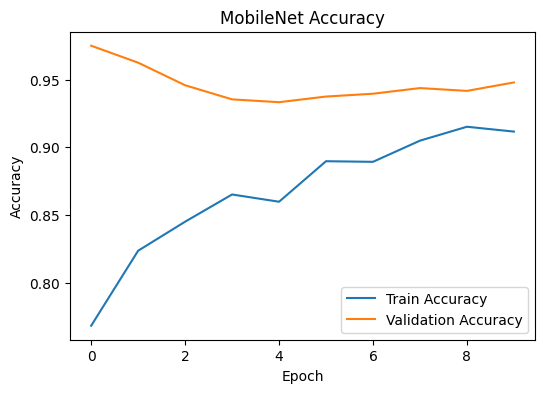

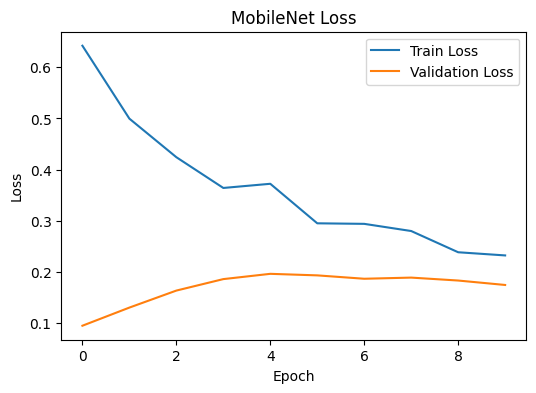

In [109]:
# plot for accuracy
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(6,4))

plt.plot(history_efficient_finetune.history['accuracy'], label='Train Accuracy')
plt.plot(history_efficient_finetune.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNet Accuracy")

plt.legend()
plt.show()

# plot for loss
# Loss plot
plt.figure(figsize=(6,4))

plt.plot(history_efficient_finetune.history['loss'], label='Train Loss')
plt.plot(history_efficient_finetune.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNet Loss")

plt.legend()
plt.show()

In [110]:
# evaluate on test data
test_loss, test_acc = model_efficient.evaluate(test_generator1)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 630ms/step - accuracy: 0.9439 - loss: 0.1926
Test Accuracy: 0.9438669681549072
Test Loss: 0.19262103736400604


16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 692ms/step
['Benign', 'Early_Pre_B', 'Pre_B', 'Pro_B']
              precision    recall  f1-score   support

      Benign       0.91      0.90      0.90        77
 Early_Pre_B       0.98      0.91      0.94       147
       Pre_B       0.89      1.00      0.94       143
       Pro_B       1.00      0.95      0.97       114

    accuracy                           0.94       481
   macro avg       0.94      0.94      0.94       481
weighted avg       0.95      0.94      0.94       481

[[ 69   3   5   0]
 [  6 134   7   0]
 [  0   0 143   0]
 [  1   0   5 108]]


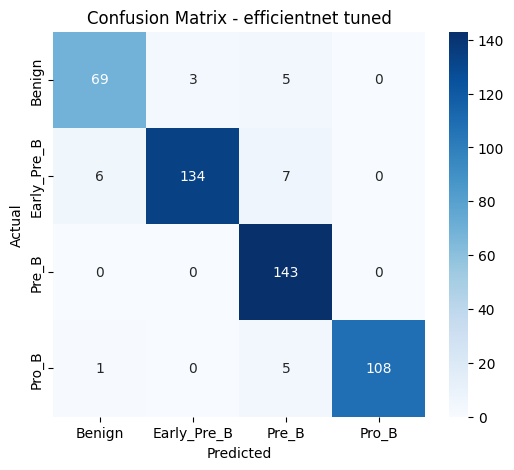

In [111]:
# Evaluation for MobileNet model

import numpy as np

# prediction on test data
y_pred_efficient_tune = model_efficient.predict(test_generator1)

# convert probabilities to class labels
y_pred_classes = np.argmax(y_pred_efficient_tune, axis=1)

# true labels
y_true = test_generator1.classes

# class names
class_names = list(test_generator1.class_indices.keys())
print(class_names)

# classification report

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=class_names))

# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)
print(cm)

# confusion matrix plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - efficientnet tuned")

plt.show()

# save EfficientNet tuned model

In [112]:
model_efficient.save("efficientnet_tuned_blood_cancer_model.keras")

# Comparisison

In [113]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [114]:
def evaluate_model(model, test_generator):

    # predictions
    y_pred_prob = model.predict(test_generator)

    y_pred = np.argmax(y_pred_prob, axis=1)

    y_true = test_generator.classes

    class_names = list(test_generator.class_indices.keys())

    # metrics
    acc = accuracy_score(y_true, y_pred)

    precision = precision_score(y_true, y_pred, average='weighted')

    recall = recall_score(y_true, y_pred, average='weighted')

    f1 = f1_score(y_true, y_pred, average='weighted')

    auc = roc_auc_score(
        tf.keras.utils.to_categorical(y_true),
        y_pred_prob,
        multi_class='ovr'
    )

    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("AUC:", auc)

    print("\nClassification Report\n")

    print(classification_report(y_true, y_pred, target_names=class_names))

    # confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    plt.show()

    return acc, precision, recall, f1, auc

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 270ms/step
Accuracy: 0.9251559251559252
Precision: 0.9239997565469263
Recall: 0.9251559251559252
F1 Score: 0.9234057091108561
AUC: 0.9860647851940338

Classification Report

              precision    recall  f1-score   support

      Benign       0.82      0.70      0.76        77
 Early_Pre_B       0.88      0.95      0.92       147
       Pre_B       0.97      0.98      0.98       143
       Pro_B       0.99      0.97      0.98       114

    accuracy                           0.93       481
   macro avg       0.92      0.90      0.91       481
weighted avg       0.92      0.93      0.92       481



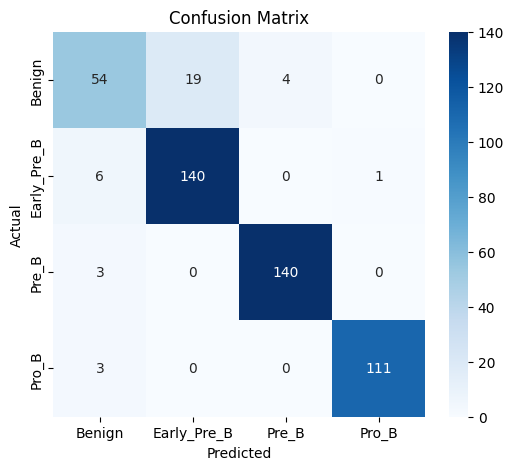

16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step
Accuracy: 0.9854469854469855
Precision: 0.9857433968825461
Recall: 0.9854469854469855
F1 Score: 0.9853977667046192
AUC: 0.9996716184092792

Classification Report

              precision    recall  f1-score   support

      Benign       0.99      0.94      0.96        77
 Early_Pre_B       0.96      0.99      0.98       147
       Pre_B       1.00      1.00      1.00       143
       Pro_B       1.00      0.99      1.00       114

    accuracy                           0.99       481
   macro avg       0.99      0.98      0.98       481
weighted avg       0.99      0.99      0.99       481



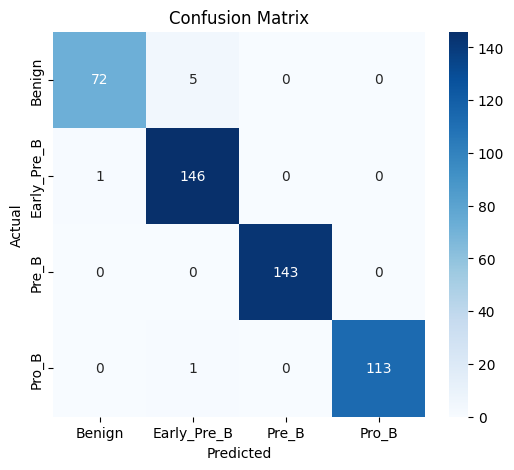

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 529ms/step
Accuracy: 0.9230769230769231
Precision: 0.9298819418063364
Recall: 0.9230769230769231
F1 Score: 0.9232604348371088
AUC: 0.994460891031397

Classification Report

              precision    recall  f1-score   support

      Benign       0.97      0.82      0.89        77
 Early_Pre_B       0.93      0.93      0.93       147
       Pre_B       0.98      0.92      0.95       143
       Pro_B       0.83      1.00      0.91       114

    accuracy                           0.92       481
   macro avg       0.93      0.91      0.92       481
weighted avg       0.93      0.92      0.92       481



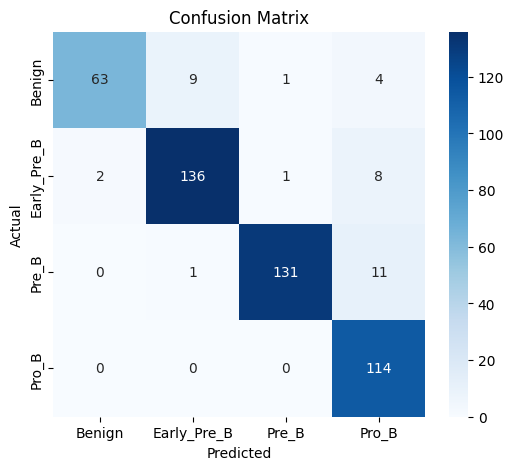

16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 662ms/step
Accuracy: 0.9438669438669439
Precision: 0.9469753984088407
Recall: 0.9438669438669439
F1 Score: 0.9440023011642404
AUC: 0.9936624344351499

Classification Report

              precision    recall  f1-score   support

      Benign       0.91      0.90      0.90        77
 Early_Pre_B       0.98      0.91      0.94       147
       Pre_B       0.89      1.00      0.94       143
       Pro_B       1.00      0.95      0.97       114

    accuracy                           0.94       481
   macro avg       0.94      0.94      0.94       481
weighted avg       0.95      0.94      0.94       481



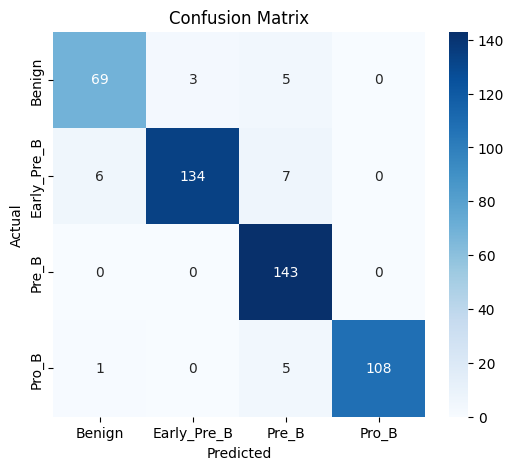

In [115]:
# custom cnn
cnn_metrics = evaluate_model(model_cnn, test_generator)

# vgg19
vgg_metrics = evaluate_model(model_vgg19, test_generator)

# mobilenet
mobilenet_metrics = evaluate_model(model_mobilenet, test_generator)

# efficientnet
efficient_metrics = evaluate_model(model_efficient, test_generator1)

In [116]:
results = pd.DataFrame({
    "Model":["CNN","VGG19","MobileNetV2","EfficientNetB0"],
    "Accuracy":[cnn_metrics[0], vgg_metrics[0], mobilenet_metrics[0], efficient_metrics[0]],
    "Precision":[cnn_metrics[1], vgg_metrics[1], mobilenet_metrics[1], efficient_metrics[1]],
    "Recall":[cnn_metrics[2], vgg_metrics[2], mobilenet_metrics[2], efficient_metrics[2]],
    "F1 Score":[cnn_metrics[3], vgg_metrics[3], mobilenet_metrics[3], efficient_metrics[3]],
    "AUC":[cnn_metrics[4], vgg_metrics[4], mobilenet_metrics[4], efficient_metrics[4]]
})

print(results)

            Model  Accuracy  Precision    Recall  F1 Score       AUC
0             CNN  0.925156   0.924000  0.925156  0.923406  0.986065
1           VGG19  0.985447   0.985743  0.985447  0.985398  0.999672
2     MobileNetV2  0.923077   0.929882  0.923077  0.923260  0.994461
3  EfficientNetB0  0.943867   0.946975  0.943867  0.944002  0.993662


# Model Comparison graph

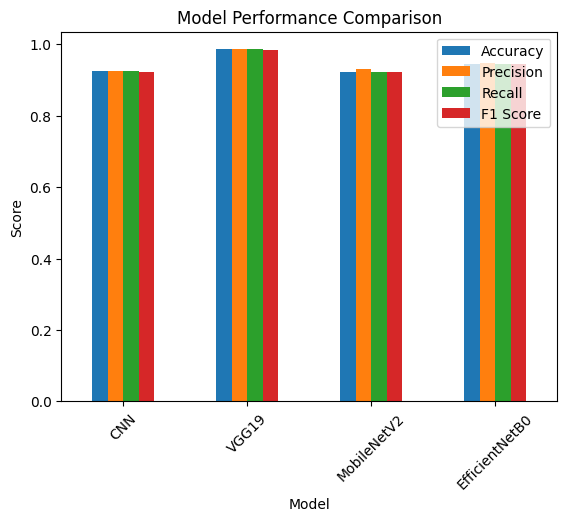

In [119]:
results.set_index("Model")[["Accuracy","Precision","Recall","F1 Score"]].plot(kind="bar")

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=45)

plt.show()